# iLQR written in Scaly: a trajectory optimizer generated as one C function

Iterative LQR is usually written by hand in C++ with hand-coded or finite-difference derivatives.
Here it is written once in Python with Scaly's loops and derivatives, and **the whole solver —
rollouts, backward Riccati pass, line search and regularization — compiles to a single C
function** with no external dependency.

| Scaly feature | Where |
| --- | --- |
| `sc.scan` (forward, and backwards with negative strides) | rollout, backward pass, policy rollout |
| `sc.while_loop` with `params` and `index=True`, nested | line search inside the outer iteration |
| `sc.jacobian`, `sc.gradient`, `sc.hessian` inside a loop body | the local LQ model at every stage |
| dense `linalg.cholesky` | the gains $K_k$, $k_k$ |
| calling a loop body `Function` numerically | watching the algorithm iterate from Python |

The script version is `examples/ilqr.py`.

In [1]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Circle

import plotstyle
import scaly as sc
from scaly import linalg
from scaly.codegen import write_module

plotstyle.use()
GENERATED = Path.cwd().parent / "generated" / "ilqr"

## The problem

A car-like robot with state $x = (p_x, p_y, h, v)$ (position, heading, speed) and input
$u = (a, \kappa)$ (acceleration, path curvature), discretized with $\Delta t = 0.1$ s:

$$
p_x^+ = p_x + \Delta t\, v \cos h,\quad p_y^+ = p_y + \Delta t\, v \sin h,\quad h^+ = h + \Delta t\, v \kappa,\quad v^+ = v + \Delta t\, a .
$$

It must park at $(6, 2.5)$ facing north, at rest, within $N = 60$ steps, past two circular
obstacles. The cost is

$$
J = \sum_{k=0}^{N-1} \Delta t\Big(\tfrac12 \lVert x_k - x_g\rVert_Q^2 + \tfrac12 \lVert u_k\rVert_R^2 + \sum_i w\, e^{-(\lVert p_k - o_i\rVert^2 - r_i^2)/\sigma}\Big) + \tfrac12 \lVert x_N - x_g\rVert_{Q_N}^2 ,
$$

where the exponential term is a smooth penalty that grows quickly inside each obstacle's radius.

In [2]:
NX, NU, N, DT = 4, 2, 60, 0.1
Q = np.diag([0.0, 0.0, 0.0, 0.1])
R = np.diag([0.05, 0.5])
QF = np.diag([100.0, 100.0, 50.0, 10.0])
OBSTACLES = np.array([[2.0, 0.6, 0.6], [4.0, 1.7, 0.5]])  # (x, y, radius)
PENALTY, SOFTNESS = 20.0, 0.1
MAX_OUTER, MAX_LINE_SEARCH, TOL = 200, 12, 1e-10
MU_MIN, MU_MAX = 1e-8, 1e10
X0, GOAL = np.zeros(NX), np.array([6.0, 2.5, np.pi / 2, 0.0])


def step(x, u):
  px, py, h, v = x[0], x[1], x[2], x[3]
  return sc.stack([px + DT * v * h.cos(), py + DT * v * h.sin(), h + DT * v * u[1], v + DT * u[0]])


def stage_cost(x, u, goal):
  e = x - goal
  cost = 0.5 * (e @ sc.const(Q) @ e) + 0.5 * (u @ sc.const(R) @ u)
  for ox, oy, radius in OBSTACLES:
    gap = (x[0] - ox) ** 2 + (x[1] - oy) ** 2 - radius**2
    cost = cost + PENALTY * (-gap / SOFTNESS).exp()
  return cost * DT


def terminal_cost(x, goal):
  e = x - goal
  return 0.5 * (e @ sc.const(QF) @ e)

## Loop 1: the rollout

A `scan` whose carry is the state; each step reads one input $u_k$ (a slice of `us` with stride
`NU`) and the goal (stride 0: the same slice every step), and stacks the visited states and the
stage costs.

In [3]:
@sc.function(sc.G(sc.L("x", NX), sc.L("u", NU), sc.L("goal", NX)), output=sc.G(sc.L("x_next", NX), sc.L("x_k", NX), sc.L("cost", 1)))
def rollout_step(inputs):
  x, u, goal = inputs
  return step(x, u), x, stage_cost(x, u, goal).reshape((1,))


def rollout(x0, us, goal):
  x_final, xs, costs = sc.scan(rollout_step, x0, [(us, 0, NU), (goal, 0, 0)], length=N)
  return x_final, xs, costs.sum() + terminal_cost(x_final, goal)

## Loop 2: the backward pass

Backwards over the horizon, carrying the value function's gradient $V_x$ and Hessian $V_{xx}$. At
each stage the local model comes from AD — $f_x, f_u$ by `sc.jacobian`, $\ell_x, \ell_u$ by
`sc.gradient`, $\ell_{xx}, \ell_{uu}$ by `sc.hessian` and $\ell_{ux}$ as a Jacobian of a
gradient — and

$$
\begin{aligned}
Q_x &= \ell_x + f_x^\top V_x, & Q_u &= \ell_u + f_u^\top V_x,\\
Q_{xx} &= \ell_{xx} + f_x^\top V_{xx} f_x, & Q_{uu} &= \ell_{uu} + f_u^\top V_{xx} f_u + \mu I, & Q_{ux} &= \ell_{ux} + f_u^\top V_{xx} f_x,\\
k &= -Q_{uu}^{-1} Q_u, & K &= -Q_{uu}^{-1} Q_{ux}. &&
\end{aligned}
$$

The scan reads $x_k$ and $u_k$ **backwards** (start at the last slice, negative stride), and emits
the gains in the order $N-1, \dots, 0$. It also emits the two terms of the predicted cost change,
$\Delta J(\alpha) = \alpha \sum k^\top Q_u + \tfrac{\alpha^2}{2} \sum k^\top Q_{uu} k$, which the line
search tests against.

If $Q_{uu} + \mu I$ is not positive definite the generated Cholesky returns NaN, the gains are NaN
and every trial cost is NaN; a NaN never passes the acceptance test, so the outer loop simply
raises $\mu$. The NaN is the error signal; no extra check is needed.

In [4]:
@sc.function(
  sc.G(sc.L("value", NX + NX * NX), sc.L("x", NX), sc.L("u", NU), sc.L("goal_mu", NX + 1)),
  output=sc.G(sc.L("value_prev", NX + NX * NX), sc.L("gains", NU + NU * NX), sc.L("dv", 2)),
)
def backward_step(inputs):
  value, x, u, goal_mu = inputs
  goal, mu = goal_mu[:NX], goal_mu[NX]
  vx, vxx = value[:NX], value[NX:].reshape((NX, NX))
  x_next, cost = step(x, u), stage_cost(x, u, goal)
  fx, fu = sc.jacobian(x_next, x), sc.jacobian(x_next, u)
  lx, lu = sc.gradient(cost, x), sc.gradient(cost, u)
  qx, qu = lx + fx.T @ vx, lu + fu.T @ vx
  qxx = sc.hessian(cost, x) + fx.T @ vxx @ fx
  quu = sc.hessian(cost, u) + fu.T @ vxx @ fu
  qux = sc.jacobian(lu, x) + fu.T @ vxx @ fx
  chol = linalg.cholesky(quu + sc.const(np.eye(NU)) * mu)
  k = -linalg.cho_solve(chol, qu)
  gain = -linalg.cho_solve(chol, qux)
  vx_prev = qx + gain.T @ (quu @ k) + gain.T @ qu + qux.T @ k
  vxx_prev = qxx + gain.T @ quu @ gain + gain.T @ qux + qux.T @ gain
  vxx_prev = 0.5 * (vxx_prev + vxx_prev.T)
  dv = sc.stack([k @ qu, 0.5 * (k @ (quu @ k))])
  return sc.concat([vx_prev, vxx_prev.reshape((NX * NX,))]), sc.concat([k, gain.reshape((NU * NX,))]), dv

## Loop 3: the line search

Roll out the feedback policy $u_k = \bar u_k + \alpha k_k + K_k(x_k - \bar x_k)$ for
$\alpha = 1, \tfrac12, \tfrac14, \dots$ until the actual decrease is at least $10^{-4}$ of the
predicted one. The trial number comes from `while_loop(..., index=True)`, so
$\alpha = 2^{-\text{trial}}$ needs no carry of its own; the nominal trajectory, the gains and the
current cost are loop `params` (read by every trial, copied by none). The policy rollout reads the
gains with a negative stride because the backward pass produced them in reverse order.

In [5]:
@sc.function(
  sc.G(sc.L("x", NX), sc.L("x_nom", NX), sc.L("u_nom", NU), sc.L("gains", NU + NU * NX), sc.L("alpha_goal", 1 + NX)),
  output=sc.G(sc.L("x_next", NX), sc.L("u", NU), sc.L("cost", 1)),
)
def policy_step(inputs):
  x, x_nom, u_nom, gains, alpha_goal = inputs
  alpha, goal = alpha_goal[0], alpha_goal[1:]
  u = u_nom + alpha * gains[:NU] + gains[NU:].reshape((NU, NX)) @ (x - x_nom)
  return step(x, u), u, stage_cost(x, u, goal).reshape((1,))


LS = N * NU + 3  # carry: (accepted, cost, alpha, inputs)
PARAMS = sc.G(sc.L("x0", NX), sc.L("goal", NX), sc.L("xs", N * NX), sc.L("us", N * NU), sc.L("gains", N * (NU + NU * NX)), sc.L("j_dv", 3))


@sc.function(sc.G(sc.L("carry", LS), sc.L("trial", sc.TensorType((), sc.dtypes.int64)), PARAMS), output=sc.L("carry_next", LS))
def line_search_step(inputs):
  _, trial, (x0, goal, xs, us, gains, j_dv) = inputs
  alpha = sc.const(0.5) ** trial.cast("float64")
  last = (N - 1) * (NU + NU * NX)
  x_final, u_new, costs = sc.scan(
    policy_step, x0, [(xs, 0, NX), (us, 0, NU), (gains, last, -(NU + NU * NX)), (sc.concat([alpha.reshape((1,)), goal]), 0, 0)], length=N
  )
  cost = costs.sum() + terminal_cost(x_final, goal)
  accepted = sc.less(cost - j_dv[0], 1e-4 * (alpha * j_dv[1] + alpha * alpha * j_dv[2]))
  return sc.concat([sc.cast(accepted, "float64").reshape((1,)), cost.reshape((1,)), alpha.reshape((1,)), u_new])


@sc.function(sc.G(sc.L("carry", LS), PARAMS), output=sc.L("go_on", ...))
def not_accepted(inputs):
  return sc.less(inputs[0][0], 0.5)

## The outer iteration and the solver

One iLQR iteration = rollout, backward pass, line search, and a Levenberg–Marquardt update of
$\mu$ (divide by 10 after a successful step, multiply by 10 after a failed one). The iteration is a
`Function` of the carry $(u_{0:N-1}, J, \mu, \text{done})$, and `ilqr` wraps it in a `while_loop`.

In [6]:
OUTER = N * NU + 3  # carry: (inputs, cost, mu, done)


@sc.function(sc.G(sc.L("carry", OUTER), sc.L("x0", NX), sc.L("goal", NX)), output=sc.L("carry_next", OUTER))
def ilqr_iteration(inputs):
  carry, x0, goal = inputs
  us, mu = carry[: N * NU], carry[N * NU + 1]
  x_final, xs, cost = rollout(x0, us, goal)
  terminal = sc.concat([sc.gradient(terminal_cost(x_final, goal), x_final), sc.hessian(terminal_cost(x_final, goal), x_final).reshape((NX * NX,))])
  goal_mu = sc.concat([goal, mu.reshape((1,))])
  _, gains, dv = sc.scan(backward_step, terminal, [(xs, (N - 1) * NX, -NX), (us, (N - 1) * NU, -NU), (goal_mu, 0, 0)], length=N)
  j_dv = sc.stack([cost, dv.reshape((N, 2))[:, 0].sum(), dv.reshape((N, 2))[:, 1].sum()])
  start = sc.concat([sc.const(np.zeros(3)), us])
  ls, _ = sc.while_loop(not_accepted, line_search_step, start, max_iter=MAX_LINE_SEARCH, index=True, params=(x0, goal, xs, us, gains, j_dv))
  accepted = sc.greater(ls[0], 0.5)
  us_next = sc.where(accepted, ls[3:], us)
  cost_next = sc.where(accepted, ls[1], cost)
  mu_next = sc.where(accepted, sc.maximum(mu * 0.1, MU_MIN), mu * 10.0)
  improvement = (cost - cost_next) / sc.maximum(cost.abs(), 1.0)
  done = sc.logical_or(sc.logical_and(accepted, sc.less(improvement, TOL)), sc.greater(mu_next, MU_MAX))
  return sc.concat([us_next, cost_next.reshape((1,)), mu_next.reshape((1,)), sc.cast(done, "float64").reshape((1,))])


@sc.function(sc.G(sc.L("carry", OUTER), sc.L("x0", NX), sc.L("goal", NX)), output=sc.L("go_on", ...))
def not_done(inputs):
  return sc.less(inputs[0][N * NU + 2], 0.5)


@sc.function(
  sc.G(sc.L("x0", NX), sc.L("goal", NX)),
  output=sc.G(sc.L("us", (N, NU)), sc.L("xs", (N + 1, NX)), sc.L("cost", ()), sc.L("iterations", ()), sc.L("mu", ())),
)
def ilqr(inputs):
  x0, goal = inputs
  start = sc.concat([sc.const(np.zeros(N * NU)), sc.const(np.array([np.inf, 1.0, 0.0]))])
  carry, n_iter = sc.while_loop(not_done, ilqr_iteration, start, max_iter=MAX_OUTER, params=(x0, goal))
  us = carry[: N * NU]
  x_final, xs, cost = rollout(x0, us, goal)
  return us.reshape((N, NU)), sc.concat([xs, x_final]).reshape((N + 1, NX)), cost, n_iter, carry[N * NU + 1]

## Solving

The first call generates and compiles the solver; the second is timed.

In [7]:
start = time.perf_counter()
ilqr((X0, GOAL))
print(f"first call (generate and compile, or load from the JIT cache): {time.perf_counter() - start:.2f} s")
start = time.perf_counter()
us, xs, cost, iterations, mu = ilqr((X0, GOAL))
elapsed = time.perf_counter() - start
print(f"solve: {1e3 * elapsed:.2f} ms for {int(iterations)} iterations ({1e6 * elapsed / iterations:.1f} us per iteration); cost {float(cost):.6f}")
print(f"final pose error: {np.array2string(xs[-1] - GOAL, precision=4)}")

first call (generate and compile, or load from the JIT cache): 0.67 s
solve: 1.05 ms for 39 iterations (27.0 us per iteration); cost 0.773875
final pose error: [-0.0013 -0.0006 -0.0053  0.0101]


## Watching it iterate

Every piece is an ordinary `Function`, so the outer iteration can also be driven from Python, one
call per iteration, to record what the single C call does internally. `trajectory` rolls out a
given input sequence for plotting.

In [8]:
@sc.function(sc.G(sc.L("us", N * NU), sc.L("x0", NX), sc.L("goal", NX)), output=sc.G(sc.L("xs", (N + 1) * NX), sc.L("cost", ())))
def trajectory(inputs):
  us_, x0, goal = inputs
  x_final, xs_, cost_ = rollout(x0, us_, goal)
  return sc.concat([xs_, x_final]), cost_


carry = np.r_[np.zeros(N * NU), np.inf, 1.0, 0.0]
history = [carry]
while carry[-1] < 0.5 and len(history) <= MAX_OUTER:
  carry = ilqr_iteration((carry, X0, GOAL))
  history.append(carry)
costs = np.array([trajectory((h[: N * NU], X0, GOAL))[1] for h in history])
mus = np.array([h[N * NU + 1] for h in history])
paths = [trajectory((h[: N * NU], X0, GOAL))[0].reshape(N + 1, NX) for h in history]
print(f"{len(history) - 1} iterations from Python, final cost {costs[-1]:.6f} (one C call: {float(cost):.6f})")

39 iterations from Python, final cost 0.773875 (one C call: 0.773875)


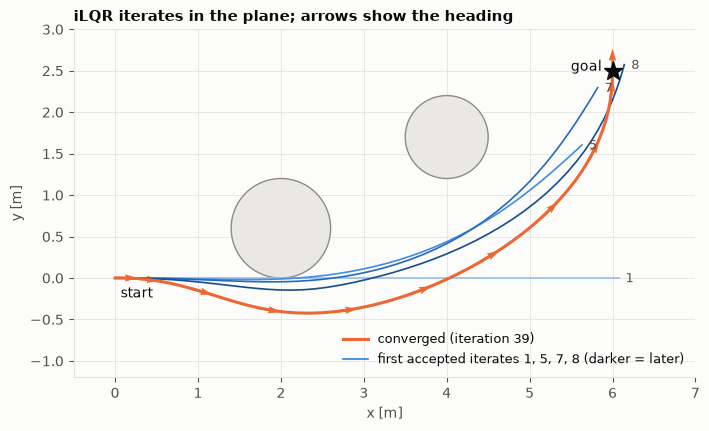

In [9]:
fig, ax = plt.subplots(figsize=(8, 4.2))
for ox, oy, r in OBSTACLES:
  ax.add_patch(Circle((ox, oy), r, facecolor="#e9e8e4", edgecolor=plotstyle.NEUTRAL, lw=1))
accepted_steps = [i for i in range(1, len(costs)) if costs[i] < costs[i - 1]]  # iterations whose step was accepted
shown = accepted_steps[:4]
for rank, i in enumerate(shown):
  shade = plotstyle.BLUES(0.3 + 0.55 * rank / (len(shown) - 1))
  ax.plot(paths[i][:, 0], paths[i][:, 1], color=shade, lw=1.2)
  ax.annotate(f"{i}", paths[i][-1, :2], xytext=(5, -3), textcoords="offset points", color=plotstyle.TEXT_SECONDARY, fontsize=9)
ax.plot(paths[-1][:, 0], paths[-1][:, 1], color=plotstyle.ORANGE, lw=2.2, label=f"converged (iteration {len(paths) - 1})")
step_arrows = slice(0, N + 1, 6)
ax.quiver(xs[step_arrows, 0], xs[step_arrows, 1], np.cos(xs[step_arrows, 2]), np.sin(xs[step_arrows, 2]), color=plotstyle.ORANGE, scale=28, width=0.004)
ax.plot(*GOAL[:2], "*", ms=14, color=plotstyle.TEXT, zorder=5)
ax.annotate("goal", GOAL[:2], xytext=(-30, 0), textcoords="offset points")
ax.annotate("start", X0[:2], xytext=(4, -14), textcoords="offset points")
ax.plot([], [], color=plotstyle.BLUES(0.55), lw=1.2, label=f"first accepted iterates {', '.join(map(str, shown))} (darker = later)")
ax.set_aspect("equal")
ax.set_xlim(-0.5, 7)
ax.set_ylim(-1.2, 3.0)
ax.set_title("iLQR iterates in the plane; arrows show the heading")
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.legend(loc="lower right", fontsize=9)
plt.show()

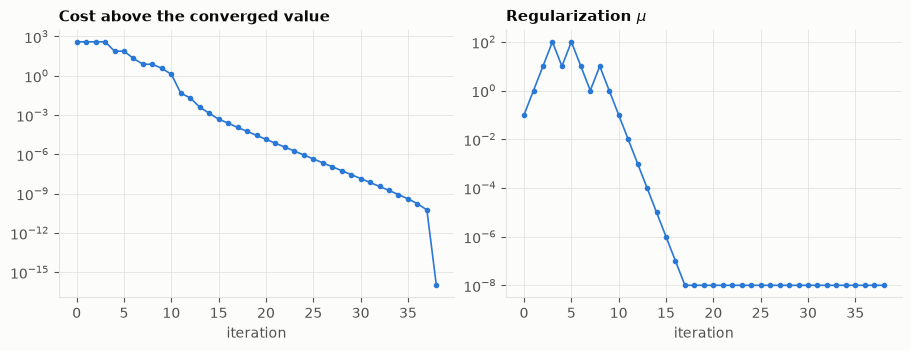

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3.4))
ax1.semilogy(costs[1:] - costs[-1] + 1e-16, "o-", ms=3, lw=1.2, color=plotstyle.BLUE)
ax1.set_title("Cost above the converged value")
ax1.set_xlabel("iteration")
ax2.semilogy(mus[1:], "o-", ms=3, lw=1.2, color=plotstyle.BLUE)
ax2.set_title(r"Regularization $\mu$")
ax2.set_xlabel("iteration")
plt.show()

The first iterate (all inputs zero) leaves the car parked at the start. Early on, the local model
is poor: steps get rejected, and $\mu$ climbs until the regularized steps are short enough to be
accepted. Once the iterates are close, every step is accepted and $\mu$ falls to its floor. From
there the convergence is *linear* (a straight line on the log scale): iLQR drops the second
derivatives of the dynamics from $Q_{xx}, Q_{uu}, Q_{ux}$, a Gauss–Newton approximation, so it does
not have Newton's quadratic rate. (Adding $V_x \cdot f_{xx}$ and friends gives DDP.)

## The inputs, and a check of optimality

At a (local) minimum of the single-shooting cost $J(u_{0:N-1})$ its gradient vanishes. Scaly gives
that gradient by one reverse sweep through the rollout scan, independently of the iLQR machinery.

|dJ/du|_inf at the iLQR solution: 8.8e-07


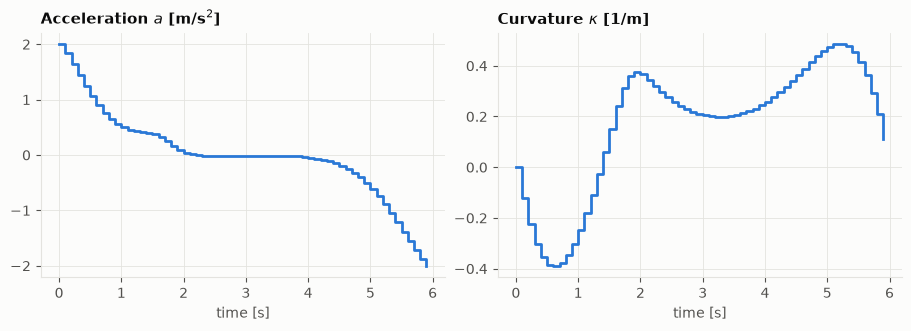

In [11]:
@sc.function(sc.G(sc.L("us", N * NU), sc.L("x0", NX), sc.L("goal", NX)), output=sc.L("grad", N * NU))
def shooting_gradient(inputs):
  us_, x0, goal = inputs
  return sc.gradient(rollout(x0, us_, goal)[2], us_)


print(f"|dJ/du|_inf at the iLQR solution: {np.abs(shooting_gradient((us.reshape(-1), X0, GOAL))).max():.1e}")
t = DT * np.arange(N)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3.2), sharex=True)
ax1.step(t, us[:, 0], where="post", color=plotstyle.BLUE)
ax1.set_title(r"Acceleration $a$ [m/s$^2$]")
ax1.set_xlabel("time [s]")
ax2.step(t, us[:, 1], where="post", color=plotstyle.BLUE)
ax2.set_title(r"Curvature $\kappa$ [1/m]")
ax2.set_xlabel("time [s]")
plt.show()

## The generated C

`write_module(ilqr, ...)` renders the complete solver: one exported function, the loop bodies as
`static inline` callees, and no heap allocation. The scratch space the caller must provide is given in the
header as `ilqr_SZ_W`; here every temporary fits in local arrays, so it is zero.

In [12]:
module = write_module(ilqr, GENERATED)
print(f"{module.source_name}: {len(module.source.splitlines())} lines; workspace {module.workspace_size} doubles ({8 * module.workspace_size / 1024:.0f} KiB)")
print("\n".join(line for line in module.header.splitlines() if line.startswith("int ") or "_SZ_" in line))

ilqr.c: 472 lines; workspace 0 doubles (0 KiB)
#define ilqr_SZ_ARG 2
#define ilqr_SZ_RES 5
#define ilqr_SZ_IW 0
#define ilqr_SZ_W 0
int ilqr(const double** arg, double** res, int* iw, double* w, int mem);
typedef struct { SCALY_ALIGNAS(16) double data[ilqr_SZ_W > 0 ? ilqr_SZ_W : 1]; } ilqr_workspace_t;
  const double* arg[ilqr_SZ_ARG > 0 ? ilqr_SZ_ARG : 1] = {x0->data, goal->data};
  double* res[ilqr_SZ_RES > 0 ? ilqr_SZ_RES : 1] = {us->data, xs->data, cost->data, iterations->data, mu->data};
